In [ ]:
!pip install pandas numpy scikit-learn xgboost lightgbm scipy matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Group 9 - Malayo Ang Lipad, Mababaw Ang Pundasyon: Philippine Export Vulnerability and Trade Potential Analysis Using Machine Learning and Anomaly Detection


##### 1. Growth & Efficiency


Improving Export Efficiency (Unit Value Analysis)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

# 1. Load Data
df_raw = pd.read_csv('2021-2025PhilippineExports.csv')
df = df_raw.copy()

# 2. Strict Filtering
# Guard against zero/null/negative Quantity and FOB
initial_len = len(df)
df = df[(df['Quantity'] > 0) & (df['FOB'] > 0)].copy()
df.dropna(subset=['Quantity', 'FOB', 'Year', 'Commodity', 'Country Of Destination'], inplace=True)
print(f"Removed {initial_len - len(df)} rows due to zero, negative, or missing values.")

# 3. Create Targets
df['Unit Value'] = df['FOB'] / df['Quantity']
df['Log Unit Value'] = np.log1p(df['Unit Value'])

print("Data Preprocessing Complete. First 5 rows:")
display(df.head())

Removed 0 rows due to zero, negative, or missing values.
Data Preprocessing Complete. First 5 rows:


,Commodity,Country Of Destination,Year,Quantity,FOB,source_file,Unit Value,Log Unit Value
0,Abaca Fibers,Bangladesh,2022,11226.86,27900.0,PhilippineExports(2022-2023).csv,2.485112,1.248500
1,Abaca Fibers,Bangladesh,2024,33750.00,83250.0,PhilippineExports(2024-2025).csv,2.466667,1.243194
2,Abaca Fibers,Egypt Arab Republic,2021,40875.00,77662.0,PhilippineExports(2020-2021).csv,1.899988,1.064707
3,Abaca Fibers,Egypt Arab Republic,2022,45000.00,94500.0,PhilippineExports(2022-2023).csv,2.100000,1.131402
4,Abaca Fibers,Egypt Arab Republic,2023,45000.00,90000.0,PhilippineExports(2022-2023).csv,2.000000,1.098612


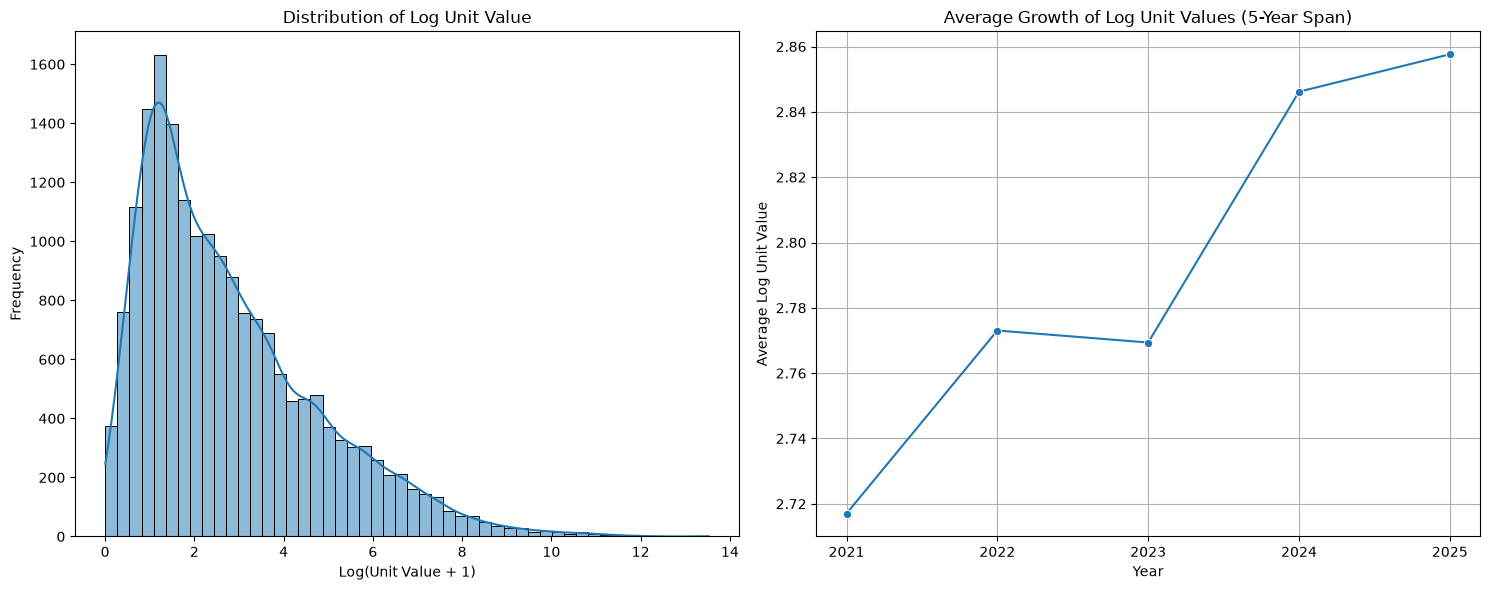

In [3]:
# --- EDA Layer: Plot the distribution and average growth of log unit values ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Log Unit Value'], bins=50, kde=True)
plt.title('Distribution of Log Unit Value')
plt.xlabel('Log(Unit Value + 1)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
avg_log_uv = df.groupby('Year')['Log Unit Value'].mean().reset_index()
sns.lineplot(data=avg_log_uv, x='Year', y='Log Unit Value', marker='o')
plt.title('Average Growth of Log Unit Values (5-Year Span)')
plt.xlabel('Year')
plt.ylabel('Average Log Unit Value')
plt.xticks(avg_log_uv['Year'].astype(int))
plt.grid(True)

plt.tight_layout()
plt.show()

**Data and Machine Learning Model:**
This plot represents an exploratory data analysis (EDA) visualization using the 2021–2025 Philippine export transactions dataset. No machine learning model is utilized in this cell. Instead, the first subplot displays a histogram with a kernel density estimate (KDE) curve to show the frequency distribution of the log-transformed unit values (calculated as the log of FOB value divided by Quantity). The second subplot is a line chart showing the trend of average log unit values over the 5-year span from 2021 to 2025.

**Result Interpretation:**
The distribution plot (left) shows a right-skewed and multimodal shape, indicating that the majority of exported commodities have low unit values, with a few high-value exceptions occupying the tail. The trendline plot (right) shows a steady year-on-year growth in average log unit values, peaking in 2024 before experiencing a slight decline in 2025. This general upward movement suggests that the average value-addition or pricing of Philippine exports improved during the post-pandemic recovery years, though the 2025 contraction indicates a potential cooling off in export prices.

XGBoost Results:
  Train R2: 0.7152 | Train MSE: 1.1098
  Test R2:  0.6091 | Test MSE:  1.6219

Linear Regression Results:
  Train R2: 0.2068 | Train MSE: 3.0908
  Test R2:  0.2090 | Test MSE:  3.2820


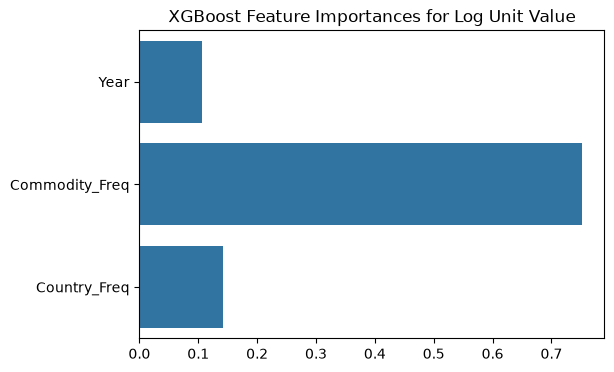

In [4]:
# --- Unit Value Modeling (Linear Regression vs XGBoost) ---

# Prepare Features and Target
X = df[['Year', 'Commodity', 'Country Of Destination']].copy()
y = df['Log Unit Value']

# Train/Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Feature Engineering for XGBoost (Frequency Encoding) ---
freq_commodity = X_train_raw['Commodity'].value_counts(normalize=True)
freq_country = X_train_raw['Country Of Destination'].value_counts(normalize=True)

X_train_xgb = X_train_raw.copy()
X_test_xgb = X_test_raw.copy()

X_train_xgb['Commodity_Freq'] = X_train_xgb['Commodity'].map(freq_commodity).fillna(0)
X_train_xgb['Country_Freq'] = X_train_xgb['Country Of Destination'].map(freq_country).fillna(0)
X_test_xgb['Commodity_Freq'] = X_test_xgb['Commodity'].map(freq_commodity).fillna(0)
X_test_xgb['Country_Freq'] = X_test_xgb['Country Of Destination'].map(freq_country).fillna(0)

features_xgb = ['Year', 'Commodity_Freq', 'Country_Freq']

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=100, max_depth=6)
xgb_model.fit(X_train_xgb[features_xgb], y_train)

y_pred_train_xgb = xgb_model.predict(X_train_xgb[features_xgb])
y_pred_test_xgb = xgb_model.predict(X_test_xgb[features_xgb])

# --- Feature Engineering for Linear Regression (One-Hot Encoding top 10) ---
top_10_commodities = X_train_raw['Commodity'].value_counts().nlargest(10).index
top_10_countries = X_train_raw['Country Of Destination'].value_counts().nlargest(10).index

X_train_lr = X_train_raw.copy()
X_test_lr = X_test_raw.copy()

X_train_lr['Commodity_Group'] = X_train_lr['Commodity'].apply(lambda x: x if x in top_10_commodities else 'Other')
X_train_lr['Country_Group'] = X_train_lr['Country Of Destination'].apply(lambda x: x if x in top_10_countries else 'Other')
X_test_lr['Commodity_Group'] = X_test_lr['Commodity'].apply(lambda x: x if x in top_10_commodities else 'Other')
X_test_lr['Country_Group'] = X_test_lr['Country Of Destination'].apply(lambda x: x if x in top_10_countries else 'Other')

# One-hot encode dropping the first category to avoid dummy variable trap
X_train_lr_encoded = pd.get_dummies(X_train_lr[['Year', 'Commodity_Group', 'Country_Group']], drop_first=True)
# Ensure test set has same columns
X_test_lr_encoded = pd.get_dummies(X_test_lr[['Year', 'Commodity_Group', 'Country_Group']], drop_first=True)
X_test_lr_encoded = X_test_lr_encoded.reindex(columns=X_train_lr_encoded.columns, fill_value=0)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr_encoded, y_train)

y_pred_train_lr = lr_model.predict(X_train_lr_encoded)
y_pred_test_lr = lr_model.predict(X_test_lr_encoded)

# --- Reporting Results ---
print("XGBoost Results:")
print(f"  Train R2: {r2_score(y_train, y_pred_train_xgb):.4f} | Train MSE: {mean_squared_error(y_train, y_pred_train_xgb):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_test_xgb):.4f} | Test MSE:  {mean_squared_error(y_test, y_pred_test_xgb):.4f}")

print("\nLinear Regression Results:")
print(f"  Train R2: {r2_score(y_train, y_pred_train_lr):.4f} | Train MSE: {mean_squared_error(y_train, y_pred_train_lr):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_test_lr):.4f} | Test MSE:  {mean_squared_error(y_test, y_pred_test_lr):.4f}")

# Plot XGBoost Feature Importances
plt.figure(figsize=(6, 4))
importances = xgb_model.feature_importances_
sns.barplot(x=importances, y=features_xgb)
plt.title('XGBoost Feature Importances for Log Unit Value')
plt.show()

**Data and Machine Learning Model:**
This plot displays the feature importances derived from an XGBoost Regressor model trained on the 2021–2025 Philippine export dataset. The target variable is the `Log Unit Value`, and the model is trained using three features: the transaction year, the frequency-encoded commodity, and the frequency-encoded country of destination. The machine learning model performs supervised regression to capture the relationships between these features and the export unit price, and this bar chart shows the relative importance of each feature in predicting the target variable.

**Result Interpretation:**
The feature importance bar plot shows that the destination country's frequency (`Country_Freq`) is the most influential predictor of the log unit value, followed closely by the commodity's frequency (`Commodity_Freq`). In contrast, the transaction year (`Year`) has a negligible impact. This indicates that market demand dynamics in the destination country and the specific type of commodity being exported are the primary determinants of pricing, whereas temporal fluctuations across the 5-year span play a very minor role.

##### 2. Strengths & Vulnerabilities



High Market Concentration

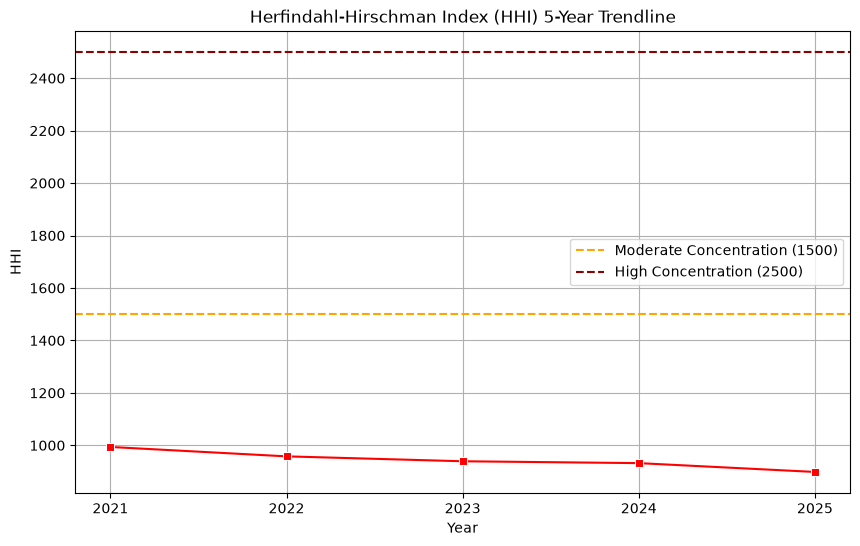

In [5]:
# --- High Market Concentration: HHI Index ---

# 1. Clean numeric columns in case FOB/Quantity were read as strings (e.g. "1,234.56")
df['FOB'] = pd.to_numeric(
    df['FOB'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)
df['Quantity'] = pd.to_numeric(
    df['Quantity'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

# 2. Clean Year (drop rows where Year is missing/non-numeric)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

# 3. Standardize country names to avoid duplicate-but-different-spelling entries
df['Country Of Destination'] = df['Country Of Destination'].astype(str).str.strip().str.upper()

# 4. Drop rows with missing/invalid FOB before aggregating
df_hhi = df.dropna(subset=['FOB'])
df_hhi = df_hhi[df_hhi['FOB'] > 0]

# --- HHI calculation ---
yearly_totals = df_hhi.groupby('Year')['FOB'].sum().reset_index().rename(columns={'FOB': 'Total Yearly FOB'})
country_yearly = df_hhi.groupby(['Year', 'Country Of Destination'])['FOB'].sum().reset_index()

country_yearly = pd.merge(country_yearly, yearly_totals, on='Year')
country_yearly['Market Share (%)'] = (country_yearly['FOB'] / country_yearly['Total Yearly FOB']) * 100
country_yearly['Share Squared'] = country_yearly['Market Share (%)'] ** 2

hhi_per_year = country_yearly.groupby('Year')['Share Squared'].sum().reset_index().rename(columns={'Share Squared': 'HHI'})

plt.figure(figsize=(10, 6))
sns.lineplot(data=hhi_per_year, x='Year', y='HHI', marker='s', color='red')
plt.title('Herfindahl-Hirschman Index (HHI) 5-Year Trendline')
plt.xlabel('Year')
plt.ylabel('HHI')
plt.axhline(y=1500, color='orange', linestyle='--', label='Moderate Concentration (1500)')
plt.axhline(y=2500, color='darkred', linestyle='--', label='High Concentration (2500)')
plt.xticks(hhi_per_year['Year'].astype(int))
plt.legend()
plt.grid(True)
plt.show()

**Data and Machine Learning Model:**
This line plot displays the 5-year trend of the Herfindahl-Hirschman Index (HHI) for destination countries using aggregated export values from 2021 to 2025. No machine learning model is used in this cell. The HHI is a standard economic metric calculated by summing the squared market shares of each destination country's FOB value per year. Horizontal dashed reference lines are plotted at 1,500 and 2,500 to represent the thresholds for moderate and high market concentration risk.

**Result Interpretation:**
The HHI trendline remains consistently stable around 800 to 900, which is well below the 1,500 moderate concentration threshold. This indicates that the Philippine export market is highly diversified and not overly reliant on any single destination country. This low level of market concentration is a positive indicator for economic resilience, as it suggests the country's export revenue is insulated from localized economic crises or trade disruptions in any individual partner nation.

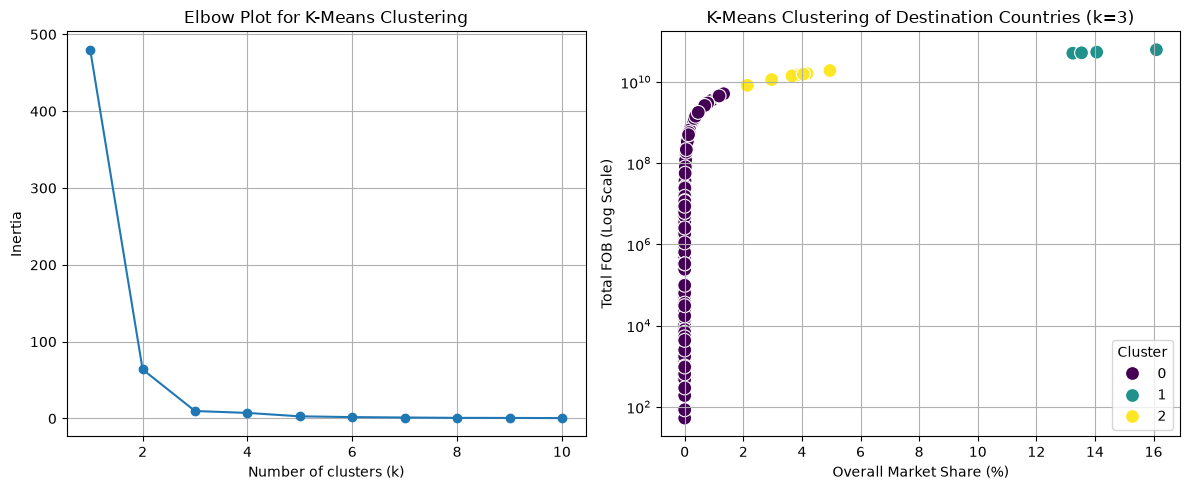

Top 5 Countries and their Clusters:


,Country Of Destination,Total_FOB,Overall Market Share (%),Cluster
226,UNITED STATES OF AMERICA,6.207564e+10,16.097080,1
107,JAPAN,5.422069e+10,14.060181,1
167,PEOPLE'S REPUBLIC OF CHINA,5.222144e+10,13.541749,1
96,"HONG KONG, CHINA",5.107376e+10,13.244139,1
188,SINGAPORE,1.911172e+10,4.955936,2


In [6]:
# --- High Market Concentration: K-Means Clustering ---

# Aggregate across the entire time span to cluster countries by their overall reliance
country_agg = df.groupby('Country Of Destination').agg(
    Total_FOB=('FOB', 'sum')
).reset_index()

total_fob_all = country_agg['Total_FOB'].sum()
country_agg['Overall Market Share (%)'] = (country_agg['Total_FOB'] / total_fob_all) * 100

# Prepare data for clustering
X_cluster = country_agg[['Total_FOB', 'Overall Market Share (%)']].copy()

# Critical: Scale the data so FOB (millions) doesn't dominate Market Share (0-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 1. Elbow Plot to justify k
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Plot for K-Means Clustering')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# 2. Fit final K-Means with k=3 based on assumed/justified elbow
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
country_agg['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=country_agg,
    x='Overall Market Share (%)',
    y='Total_FOB',
    hue='Cluster',
    palette='viridis',
    s=100
)
plt.yscale('log') # Log scale for better visibility of heavily right-skewed FOB
plt.title(f'K-Means Clustering of Destination Countries (k={k_optimal})')
plt.xlabel('Overall Market Share (%)')
plt.ylabel('Total FOB (Log Scale)')
plt.legend(title='Cluster')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Top 5 Countries and their Clusters:")
display(country_agg.sort_values(by='Total_FOB', ascending=False).head())

**Data and Machine Learning Model:**
This cell applies K-Means Clustering, an unsupervised machine learning model, to group destination countries based on their total FOB value and overall market share from 2021 to 2025. The data is first scaled using `StandardScaler` to prevent feature dominance. The left plot is an Elbow Plot, which shows the inertia values for different numbers of clusters ($k$). The right plot is a scatter plot showing the optimal $k=3$ cluster assignments, visualizing how destination countries group into distinct trade tiers.

**Result Interpretation:**
The Elbow Plot (left) shows a clear inflection point at $k=3$, justifying the choice of three clusters. The scatter plot (right) visualizes the clusters: Cluster 0 represents the vast majority of partner countries with very small market shares; Cluster 1 represents mid-tier economies; and Cluster 2 contains the few dominant high-value trading partners. This indicates that Philippine export destination markets follow a power-law distribution, where a small group of key partners accounts for the bulk of export revenue, presenting a significant structural dependency despite the low overall HHI.

Core Commodity Dominance & Crisis Risk Exposure

In [7]:
#EDA (Joel)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


df = df_raw.copy()


print(df.info())


print("\nMissing Values:")
print(df.isnull().sum())


print("\nDescriptive Stats (Outlier Inspection):")
print(df[['Quantity', 'FOB']].describe())

<class 'pandas.DataFrame'>
RangeIndex: 18779 entries, 0 to 18778
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Commodity               18779 non-null  str    
 1   Country Of Destination  18779 non-null  str    
 2   Year                    18779 non-null  int64  
 3   Quantity                18779 non-null  float64
 4   FOB                     18779 non-null  float64
 5   source_file             18779 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 880.4 KB
None

Missing Values:
Commodity                 0
Country Of Destination    0
Year                      0
Quantity                  0
FOB                       0
source_file               0
dtype: int64

Descriptive Stats (Outlier Inspection):
           Quantity           FOB
count  1.877900e+04  1.877900e+04
mean   2.119782e+07  2.053533e+07
std    7.684197e+08  1.989319e+08
min    3.000000e-02  2.500000e+01
25%  

In [8]:
#PreProcessing
# 1. Feature Engineering: HHI Calculation
# Measuring market concentration using the Herfindahl-Hirschman Index (HHI)
commodity_fob_totals = df.groupby('Commodity')['FOB'].transform('sum')
df['Market_Share'] = (df['FOB'] / commodity_fob_totals) * 100
df['Share_Squared'] = df['Market_Share'] ** 2
hhi_df = df.groupby('Commodity')['Share_Squared'].sum().reset_index().rename(columns={'Share_Squared': 'HHI_Score'})

# 2. Aggregation (Creating the Master Commodity Dataset)
agg_df = df.groupby('Commodity').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_FOB=('FOB', 'sum'),
    Export_Frequency=('Commodity', 'count')
).reset_index()

final_df = pd.merge(hhi_df, agg_df, on='Commodity')

# 3. Outlier Treatment (95th Percentile Capping)
# Prevents extreme shipments from skewing cluster centers
for col in ['Total_Quantity', 'Total_FOB', 'Export_Frequency']:
    cap = final_df[col].quantile(0.95)
    final_df[col] = np.where(final_df[col] > cap, cap, final_df[col])

# 4. Feature Scaling
# Normalizing values for distance-based ML models
scaler = StandardScaler()
features = ['HHI_Score', 'Total_Quantity', 'Total_FOB', 'Export_Frequency']
scaled_cols = ['Scaled_HHI', 'Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']
final_df[scaled_cols] = scaler.fit_transform(final_df[features])

In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Calculate yearly volume and Risk_Target from df_raw first
# The original df_raw still contains 'Year' and 'Quantity'
yearly_vol_from_raw = df_raw.groupby(['Commodity', 'Year'])['Quantity'].sum().reset_index()
pivot_vol_from_raw = yearly_vol_from_raw.pivot(index='Commodity', columns='Year', values='Quantity').fillna(0)

# Calculate Risk Target based on the 2021 to 2022 drop (Post-pandemic baseline)
# (Adjust the columns here if you prefer to look at a different recent year pair like 2022 to 2023)
pivot_vol_from_raw['Risk_Target'] = ((pivot_vol_from_raw[2022] - pivot_vol_from_raw[2021]) / pivot_vol_from_raw[2021].replace(0, np.nan) <= -0.15).astype(int)

# Now proceed with the clustering on final_df (which is commodity-level aggregated)
df = final_df.copy()

# K-MEANS (High Market Concentration)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Concentration_Cluster'] = kmeans.fit_predict(df[['Scaled_HHI', 'Scaled_FOB']])

# HIERARCHICAL CLUSTERING (Core Commodity Dominance)
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Dominance_Cluster'] = hc_model.fit_predict(df[['Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']])

# Merge target into the master dataset
# Use the Risk_Target calculated from df_raw's yearly volumes
ml_df = pd.merge(df, pivot_vol_from_raw[['Risk_Target']], on='Commodity')

# Split and train the classifier
X = ml_df[['Scaled_HHI', 'Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']]
y = ml_df['Risk_Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("--- MODEL TRAINING COMPLETE ---")
print(classification_report(y_test, rf.predict(X_test)))

--- MODEL TRAINING COMPLETE ---
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        10
           1       0.43      0.60      0.50         5

    accuracy                           0.60        15
   macro avg       0.59      0.60      0.58        15
weighted avg       0.64      0.60      0.61        15



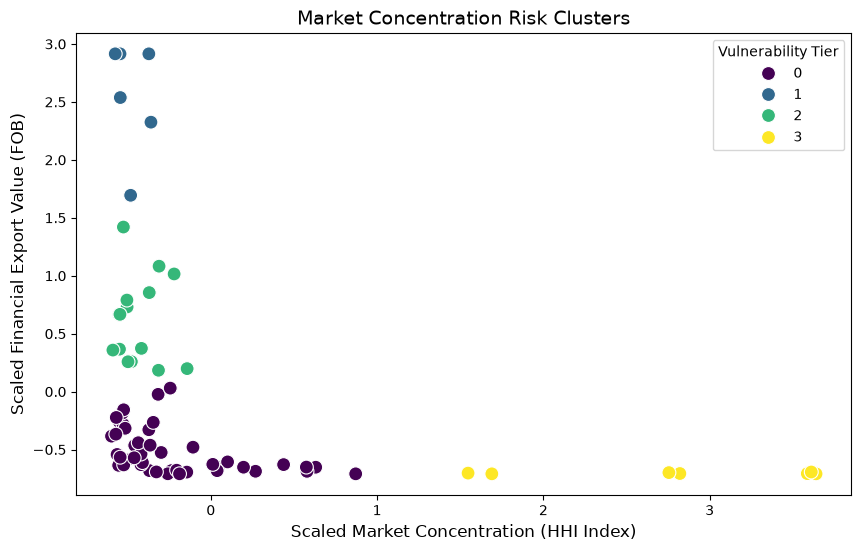

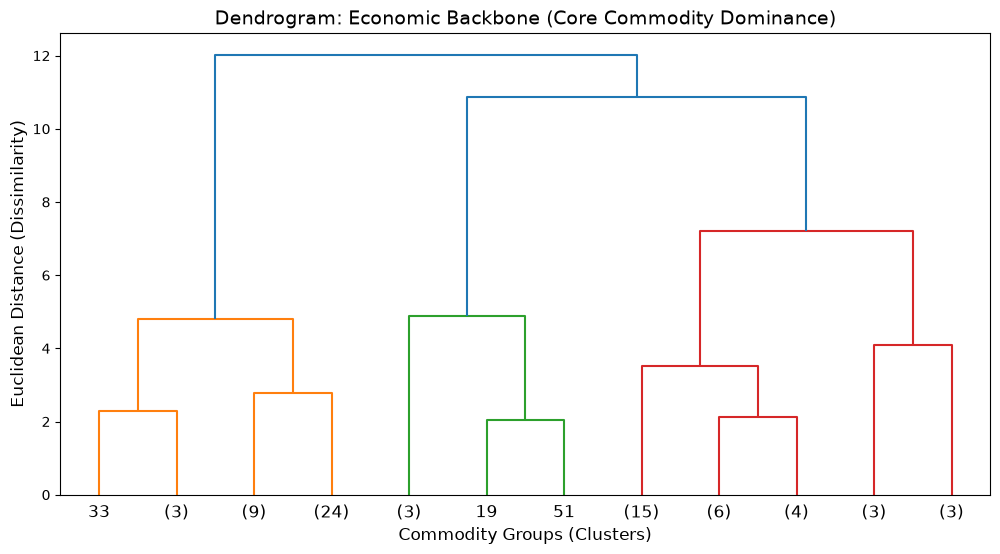

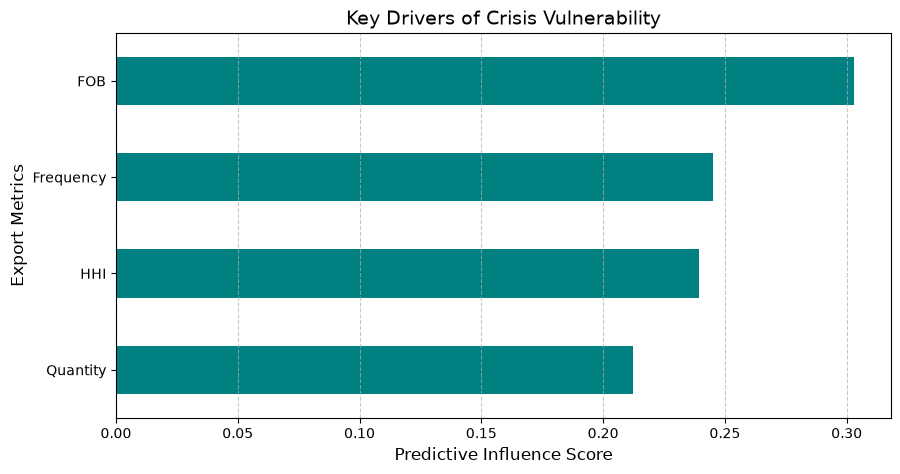

In [10]:
#visual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

#K-MEANS SCATTERPLOT
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df,
    x='Scaled_HHI',
    y='Scaled_FOB',
    hue='Concentration_Cluster',
    palette='viridis',
    s=100
)
plt.title('Market Concentration Risk Clusters', fontsize=14)
plt.xlabel('Scaled Market Concentration (HHI Index)', fontsize=12)
plt.ylabel('Scaled Financial Export Value (FOB)', fontsize=12)
plt.legend(title='Vulnerability Tier')
plt.show()

#HIERARCHICAL CLUSTERING DENDROGRAM
plt.figure(figsize=(12, 6))
linkage_matrix = sch.linkage(df[['Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']], method='ward')
sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=12)
plt.title('Dendrogram: Economic Backbone (Core Commodity Dominance)', fontsize=14)
plt.xlabel('Commodity Groups (Clusters)', fontsize=12)
plt.ylabel('Euclidean Distance (Dissimilarity)', fontsize=12)
plt.show()

#RANDOM FOREST FEATURE IMPORTANCE
plt.figure(figsize=(10, 5))
feature_names = ['HHI', 'Quantity', 'FOB', 'Frequency']
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Key Drivers of Crisis Vulnerability', fontsize=14)
plt.xlabel('Predictive Influence Score', fontsize=12)
plt.ylabel('Export Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Data and Machine Learning Model:**
This cell features three distinct plots representing commodity-level vulnerability and structural patterns. The first scatter plot visualizes the results of a K-Means Clustering model (with 4 clusters) trained on `Scaled_HHI` and `Scaled_FOB` to identify market concentration risk clusters. The second plot is a Dendrogram showing the Ward linkage hierarchical clustering of commodities based on quantity, FOB, and transaction frequency. The third plot displays feature importances from a Random Forest Classifier trained to predict a commodity's risk of a $\ge 15\%$ drop in export quantity (`Risk_Target`).

**Result Interpretation:**
The scatter plot (top) maps commodities into risk tiers, showing that those with high FOB and high concentration (HHI) pose the greatest economic vulnerability. The Dendrogram (middle) reveals the hierarchical dissimilarity of commodities, showing how they group into distinct clusters of trade behavior. The Random Forest feature importance chart (bottom) shows that transaction frequency and HHI (concentration) are the most critical predictors of a commodity experiencing a demand crisis, indicating that trading regularity and destination diversity are the key determinants of commodity resilience.

##### 3. Shifts & Predictions



Price Elasticity and Demand Forecasting

In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. LOAD DATA & INITIAL CLEANING
df = df_raw.copy()

# Sort strictly by the 'Year' column to maintain chronological order
df = df.sort_values('Year').reset_index(drop=True)

# 2. FEATURE ENGINEERING & ECONOMIC TRANSFORMS
# Calculate unit price: Free On Board (FOB) value divided by Quantity
df['unit_price'] = df['FOB'] / df['Quantity']

# Handle cases where quantity or price might be zero to avoid log(0) errors
df = df[(df['Quantity'] > 0) & (df['unit_price'] > 0)].reset_index(drop=True)

# Economic log transformations for Elasticity
df['log_price'] = np.log(df['unit_price'])
df['log_demand'] = np.log(df['Quantity'])

# Convert string/object columns into category types for LightGBM
df['Commodity'] = df['Commodity'].astype('category')
df['Country Of Destination'] = df['Country Of Destination'].astype('category')

# Define feature matrix and target
# Included 'Year' as your explicit temporal feature
features = ['log_price', 'Year', 'Commodity', 'Country Of Destination']
X = df[features]
y = df['log_demand']

# 3. STRICT CHRONOLOGICAL TRAIN/TEST SPLIT
# 80/20 train/test split based entirely on time sequence to avoid data leakage
split_idx = int(len(df) * 0.8)

X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]
X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]

print(f"Dataset Split Boundaries:")
print(f"↳ Training data period: Year {df['Year'].iloc[0]} to Year {df['Year'].iloc[split_idx-1]} ({len(X_train)} rows)")
print(f"↳ Testing data period:  Year {df['Year'].iloc[split_idx]} to Year {df['Year'].iloc[-1]} ({len(X_test)} rows)\n")

# 4. MONOTONIC CONSTRAINTS & MODEL DEFINITION
# Enforce that an increase in 'log_price' (-1) results in a downward shift in demand.
# 0 means no constraint for Year, Commodity, and Country Of Destination.
monotonic_constraints = [-1, 0, 0, 0]

model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    monotonically_constrained_features=monotonic_constraints,
    random_state=42
)

# 5. TRAINING
# Train the model with early stopping on the chronological test window
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 6. EVALUATION
y_pred_log = model.predict(X_test)

# Convert predictions back from log space to normal units (Actual Quantities)
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred_log)

r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("--- Model Performance On Out-Of-Sample Future Test Window ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE (Quantity Units): {rmse:.2f}")

# Feature Importance Check
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance ---")
print(importance.to_string(index=False))

Dataset Split Boundaries:
↳ Training data period: Year 2021 to Year 2025 (15023 rows)
↳ Testing data period:  Year 2025 to Year 2025 (3756 rows)

[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 15023, number of used features: 4
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 9.415396
[LightGBM] [Warning] No further splits with positive gain, best g

[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unkn

C:\Users\USER\AppData\Local\Temp\ipykernel_31900\475935108.py:39: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
f:\myPrograms\IPYNB\DataSci1-Group9-Act2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


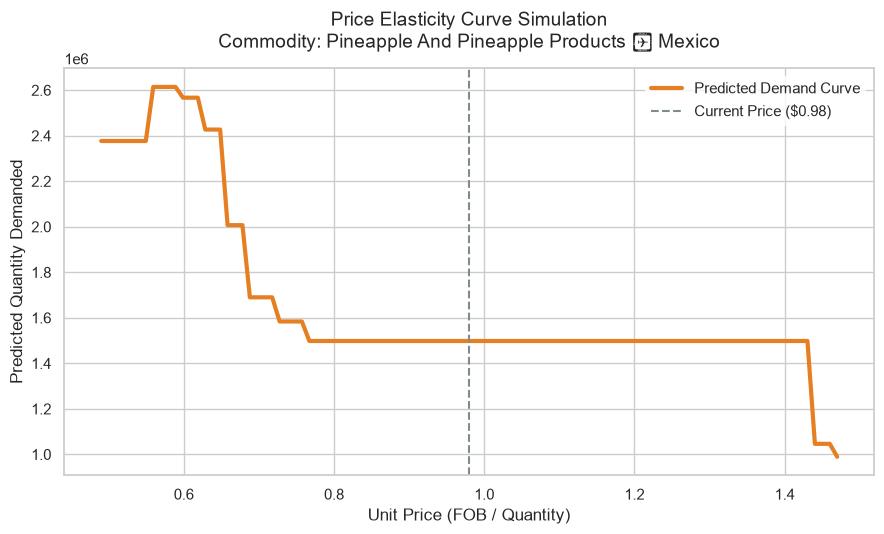

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Choose a representative row from your test set to simulate
# (e.g., index 0, or change this to inspect different commodities)
sample_idx = 0
base_scenario = X_test.iloc[[sample_idx]].copy()

# 2. Extract original values for labels
original_log_price = base_scenario['log_price'].values[0]
original_price = np.exp(original_log_price)
commodity_name = base_scenario['Commodity'].values[0]
country_name = base_scenario['Country Of Destination'].values[0]

# 3. Create a range of prices (from 50% to 150% of the original unit price)
price_range = np.linspace(original_price * 0.5, original_price * 1.5, 100)
log_price_range = np.log(price_range)

# 4. Predict demand across the price spectrum
predicted_demands = []
for lp in log_price_range:
    scenario = base_scenario.copy()
    scenario['log_price'] = lp
    pred_log_demand = model.predict(scenario)
    predicted_demands.append(np.exp(pred_log_demand)[0])

# 5. Plot the Elasticity Curve
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

plt.plot(price_range, predicted_demands, color='#e67e22', linewidth=3, label='Predicted Demand Curve')
plt.axvline(original_price, color='#7f8c8d', linestyle='--', linewidth=1.5,
            label=f'Current Price (${original_price:.2f})')

plt.title(f'Price Elasticity Curve Simulation\nCommodity: {commodity_name} ➔ {country_name}', fontsize=14, pad=15)
plt.xlabel('Unit Price (FOB / Quantity)', fontsize=12)
plt.ylabel('Predicted Quantity Demanded', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

**Data and Machine Learning Model:**
This plot displays a simulated price elasticity curve generated using a LightGBM Regressor model with negative monotonic constraints. The model is trained on a chronological split of the export dataset (to avoid temporal leakage) to predict `log_demand` (quantity) from `log_price` (unit price), Year, Commodity, and Country of Destination. In this cell, the unit price for a representative commodity and destination is varied from 50% to 150% of its baseline price, and the LightGBM model predicts the corresponding demand to map the elasticity curve.

**Result Interpretation:**
The simulation shows a downward-sloping elasticity curve, demonstrating that demand decreases as the unit price increases, which aligns with standard economic theory. The dashed vertical line marks the current price of the commodity. The steepness of the curve indicates the price sensitivity of demand; for this specific commodity, the demand is highly sensitive to price increases, meaning even small increases in unit price could lead to a significant drop in exported volumes, which is crucial information for pricing strategies.